# Loss Weighting and Spectral Bias in Diffusion Models
Exploring how different loss weighting choices affect which features a diffusion model learns first.

In [1]:
import sys
import os
import numpy as np
import math
from scipy.special import expi
from scipy.integrate import quad
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Add repo to path so we can import from core/
repo_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'DiffusionLearningCurve'))
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

from core.weighting_functions import get_weighting, list_weightings, lognormal_pdf

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

In [2]:
# Parameters
SIGMA_0 = 0.002     # min noise
SIGMA_T = 80.0      # max noise
ETA = 1.0           # learning rate
Q_K = 0.5           # initial weight scale
SIGMA_DATA = 0.5    # data std (EDM convention)

LAMBDA_K_LIST = [0.01, 0.1, 1, 10, 100]
LAMBDA_K_DENSE = np.logspace(-2, 2, 20)
TAU_CURVE = np.logspace(-4, 3, 500)

## 1. Closed-form spectral learning curves
Using the analytical solution for a 1-layer linear denoiser to see how each eigenmode's generated variance evolves during training.

In [3]:
def eval_learning_spec_func(lambdak, sigma0, sigmaT, eta, tau):
    """Spectral function using Ei(x) for the 1-layer linear denoiser."""
    exp_term0 = expi(-2 * eta * tau * sigma0**2) * np.exp(-2 * eta * tau * lambdak)
    exp_term1 = expi(-2 * eta * tau * (sigma0**2 + lambdak))
    numerator = np.exp(0.5 * (exp_term0 - exp_term1))

    exp_term2 = expi(-2 * eta * tau * sigmaT**2) * np.exp(-2 * eta * tau * lambdak)
    exp_term3 = expi(-2 * eta * tau * (sigmaT**2 + lambdak))
    denominator = np.exp(0.5 * (exp_term2 - exp_term3))

    return numerator / denominator


def eval_scaling_factor(lambdak, sigma0, sigmaT, eta, tau):
    """Generated std / sigma_T."""
    term1 = np.sqrt((lambdak + sigma0**2) / (lambdak + sigmaT**2))
    spec_func = eval_learning_spec_func(lambdak, sigma0, sigmaT, eta, tau)
    return term1 * spec_func


test_val = eval_scaling_factor(1.0, SIGMA_0, SIGMA_T, ETA, 1000) * SIGMA_T
print(f"Generated std for lambda_k=1.0 at tau=1000: {test_val:.4f} (should be ~1.0)")

Generated std for lambda_k=1.0 at tau=1000: 0.9999 (should be ~1.0)


Generated variance and normalized variance ratio vs training time.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/var/folders/4j/sptjwvys5yzg5mzqlfj9js9r0000gn/T/ipykernel_37524/3626507962.py:7: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(TAU_CURVE, gen_var, color=colors[i], label=f'$\lambda_k = {lambdak}$')
/var/folders/4j/sptjwvys5yzg5mzqlfj9js9r0000gn/T/ipykernel_37524/3626507962.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(TAU_CURVE, var_ratio, color=colors[i], label=f'$\lambda_k = {lambdak}$')


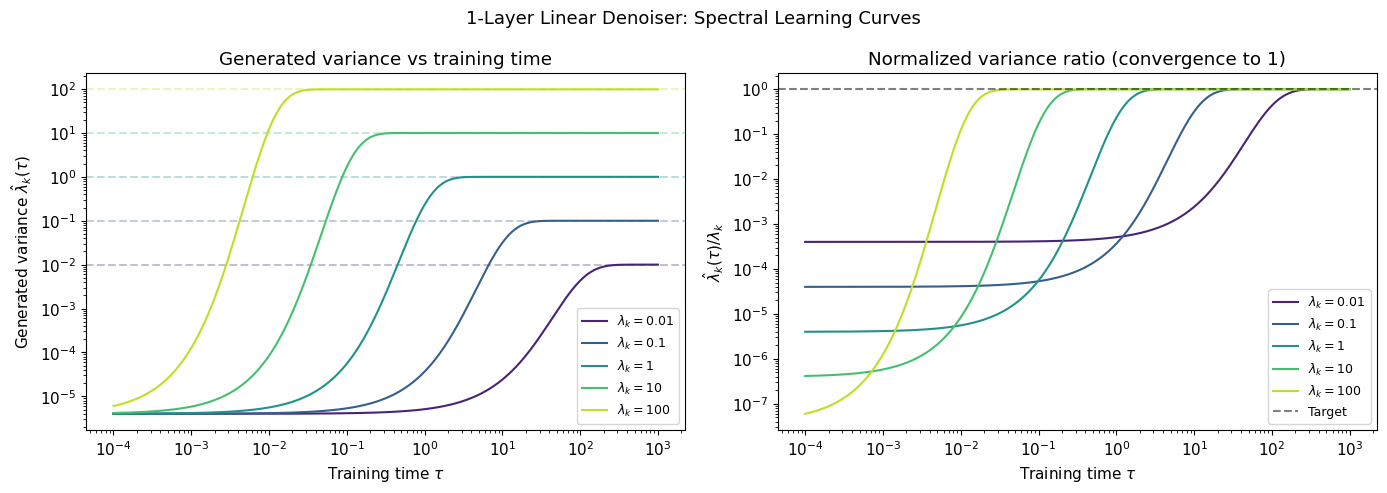

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(LAMBDA_K_LIST)))

ax = axes[0]
for i, lambdak in enumerate(LAMBDA_K_LIST):
    gen_var = (eval_scaling_factor(lambdak, SIGMA_0, SIGMA_T, ETA, TAU_CURVE) * SIGMA_T) ** 2
    ax.plot(TAU_CURVE, gen_var, color=colors[i], label=f'$\lambda_k = {lambdak}$')
    ax.axhline(y=lambdak, color=colors[i], linestyle='--', alpha=0.3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Training time $\tau$'); ax.set_ylabel(r'Generated variance $\hat{\lambda}_k(\tau)$')
ax.set_title('Generated variance vs training time'); ax.legend(fontsize=9)

ax = axes[1]
for i, lambdak in enumerate(LAMBDA_K_LIST):
    var_ratio = (eval_scaling_factor(lambdak, SIGMA_0, SIGMA_T, ETA, TAU_CURVE) * SIGMA_T) ** 2 / lambdak
    ax.plot(TAU_CURVE, var_ratio, color=colors[i], label=f'$\lambda_k = {lambdak}$')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5, label='Target')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Training time $\tau$'); ax.set_ylabel(r'$\hat{\lambda}_k(\tau) / \lambda_k$')
ax.set_title('Normalized variance ratio (convergence to 1)'); ax.legend(fontsize=9)

fig.suptitle('1-Layer Linear Denoiser: Spectral Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

Same thing on a linear y-scale -- easier to see that large-eigenvalue modes converge first.

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/var/folders/4j/sptjwvys5yzg5mzqlfj9js9r0000gn/T/ipykernel_37524/435687880.py:4: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(TAU_CURVE, var_ratio, color=colors[i], label=f'$\lambda_k = {lambdak}$', linewidth=2)


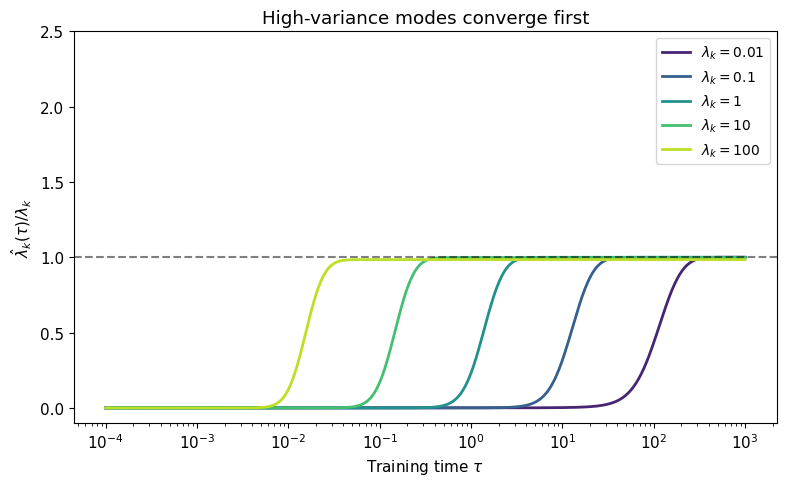

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, lambdak in enumerate(LAMBDA_K_LIST):
    var_ratio = (eval_scaling_factor(lambdak, SIGMA_0, SIGMA_T, ETA, TAU_CURVE) * SIGMA_T) ** 2 / lambdak
    ax.plot(TAU_CURVE, var_ratio, color=colors[i], label=f'$\lambda_k = {lambdak}$', linewidth=2)
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xscale('log'); ax.set_ylim(-0.1, 2.5)
ax.set_xlabel(r'Training time $\tau$'); ax.set_ylabel(r'$\hat{\lambda}_k(\tau) / \lambda_k$')
ax.set_title('High-variance modes converge first'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

Fitting the emergence time power law. We expect the exponent to be close to -1.

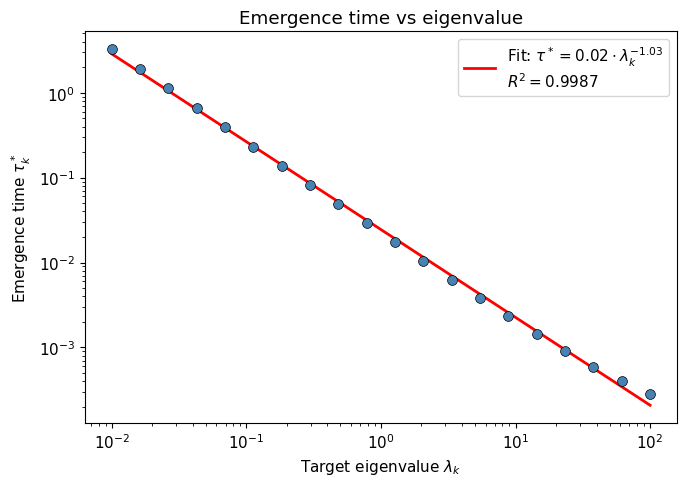

Power-law exponent: alpha = -1.035 (theory predicts -1.0)
R-squared: 0.9987


In [6]:
from scipy.ndimage import gaussian_filter1d

def compute_emergence_times(lambdak_list, sigma0, sigmaT, q_k, eta, tau_curve, threshold_type='harmonic_mean'):
    results = []
    for lambdak in lambdak_list:
        gen_var = (eval_scaling_factor(lambdak, sigma0, sigmaT, eta, tau_curve) * sigmaT) ** 2
        initial_var = gen_var[0]
        target_var = lambdak
        if threshold_type == 'harmonic_mean':
            threshold = 2 / (1 / target_var + 1 / initial_var)
        elif threshold_type == 'geometric_mean':
            threshold = np.sqrt(target_var * initial_var)
        else:
            threshold = (target_var + initial_var) / 2
        smoothed = gaussian_filter1d(gen_var, sigma=2)
        direction = 1 if smoothed[0] > threshold else -1
        if direction == 1:
            crossings = np.where(smoothed < threshold)[0]
        else:
            crossings = np.where(smoothed > threshold)[0]
        if len(crossings) > 0:
            tau_star = tau_curve[crossings[0]]
            results.append({'lambda_k': lambdak, 'tau_star': tau_star, 'direction': 'decrease' if direction == 1 else 'increase'})
        else:
            results.append({'lambda_k': lambdak, 'tau_star': np.nan, 'direction': 'none'})
    return pd.DataFrame(results)


def fit_power_law(x, y):
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    log_x = np.log(x[mask]).reshape(-1, 1)
    log_y = np.log(y[mask])
    model = LinearRegression().fit(log_x, log_y)
    a = np.exp(model.intercept_)
    b = model.coef_[0]
    r2 = model.score(log_x, log_y)
    return a, b, r2


tau_dense = np.logspace(-4, 3, 2000)
df_emerge = compute_emergence_times(LAMBDA_K_DENSE, SIGMA_0, SIGMA_T, Q_K, ETA, tau_dense)
valid = df_emerge.dropna(subset=['tau_star'])
a, b, r2 = fit_power_law(valid['lambda_k'].values, valid['tau_star'].values)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['lambda_k'], valid['tau_star'], c='steelblue', s=50, zorder=5, edgecolors='k', linewidths=0.5)
x_fit = np.logspace(np.log10(valid['lambda_k'].min()), np.log10(valid['lambda_k'].max()), 100)
ax.plot(x_fit, a * x_fit**b, 'r-', linewidth=2, label=f'Fit: $\\tau^* = {a:.2f} \\cdot \\lambda_k^{{{b:.2f}}}$\n$R^2 = {r2:.4f}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Target eigenvalue $\lambda_k$'); ax.set_ylabel(r'Emergence time $\tau_k^*$')
ax.set_title(r'Emergence time vs eigenvalue'); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f"Power-law exponent: alpha = {b:.3f} (theory predicts -1.0)")
print(f"R-squared: {r2:.4f}")

## 2. Loss weighting schemes from the literature
Each scheme below assigns different importance to different noise levels during training.

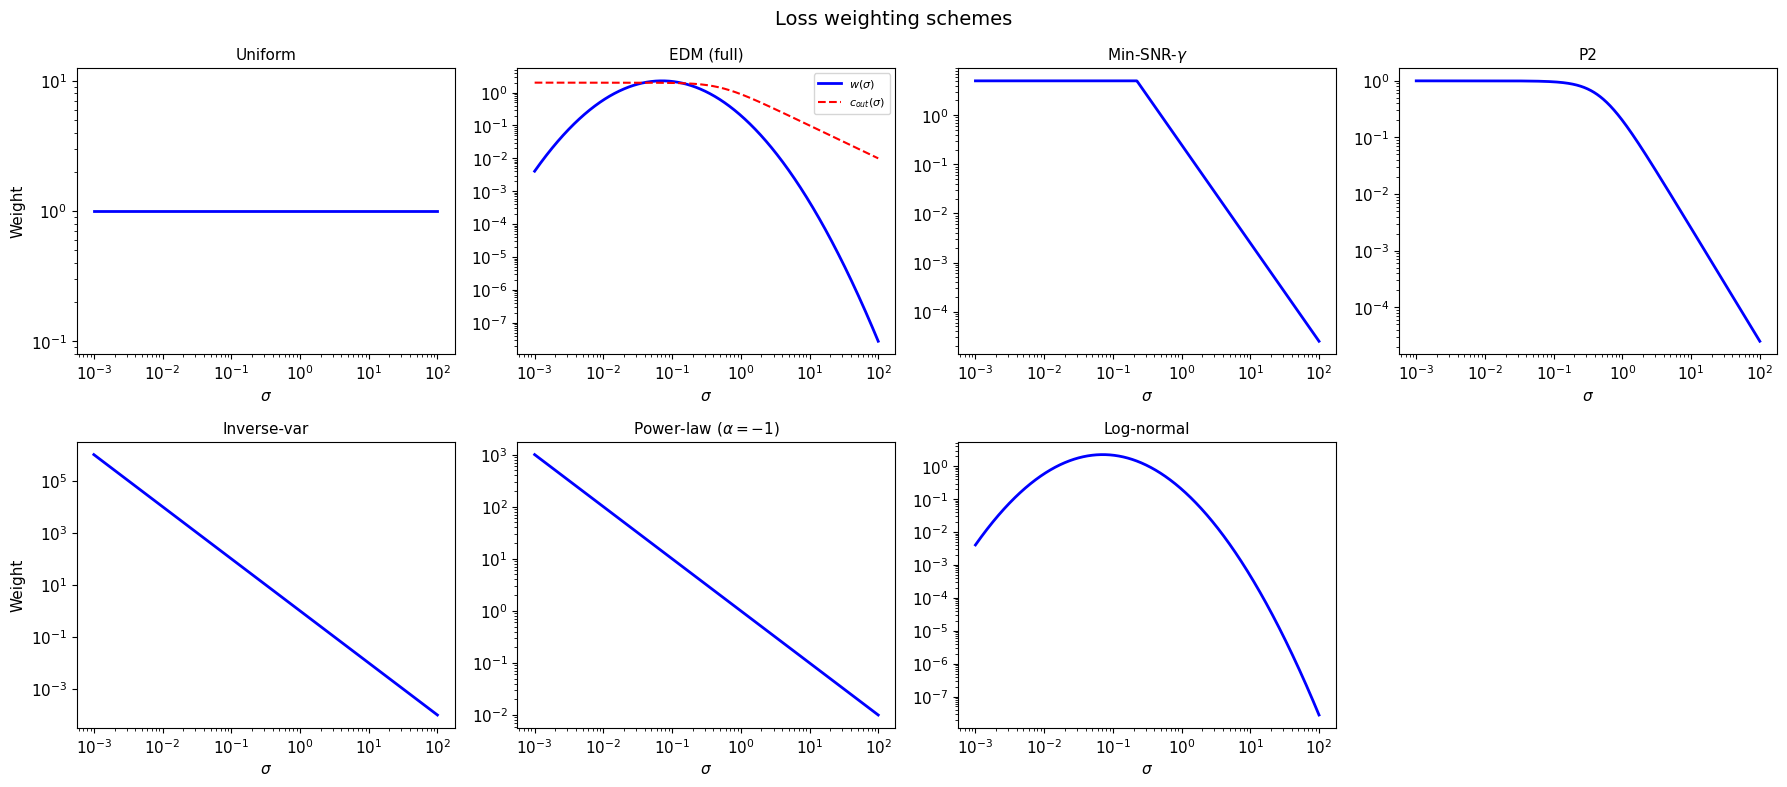

In [7]:
sigma_range = np.logspace(-3, 2, 1000)

scheme_names = ['uniform', 'edm', 'min-snr-gamma', 'p2', 'inverse-variance', 'power-law', 'lognormal-only']
scheme_labels = ['Uniform', 'EDM (full)', 'Min-SNR-$\\gamma$', 'P2', 'Inverse-var', 'Power-law ($\\alpha=-1$)', 'Log-normal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (name, label) in enumerate(zip(scheme_names, scheme_labels)):
    eta_fn, data_fn = get_weighting(name)
    ax = axes[idx]
    w_vals = np.array([eta_fn(s) for s in sigma_range])
    d_vals = np.array([data_fn(s) for s in sigma_range])
    ax.plot(sigma_range, w_vals, 'b-', linewidth=2, label='$w(\\sigma)$')
    if not np.allclose(d_vals, 1.0):
        ax.plot(sigma_range, d_vals, 'r--', linewidth=1.5, label='$c_{out}(\\sigma)$')
        ax.legend(fontsize=8)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(label, fontsize=11); ax.set_xlabel('$\\sigma$')
    if idx % 4 == 0:
        ax.set_ylabel('Weight')

axes[-1].set_visible(False)
fig.suptitle('Loss weighting schemes', fontsize=14)
plt.tight_layout(); plt.show()

Normalized overlay -- comparing which noise regimes each scheme focuses on.

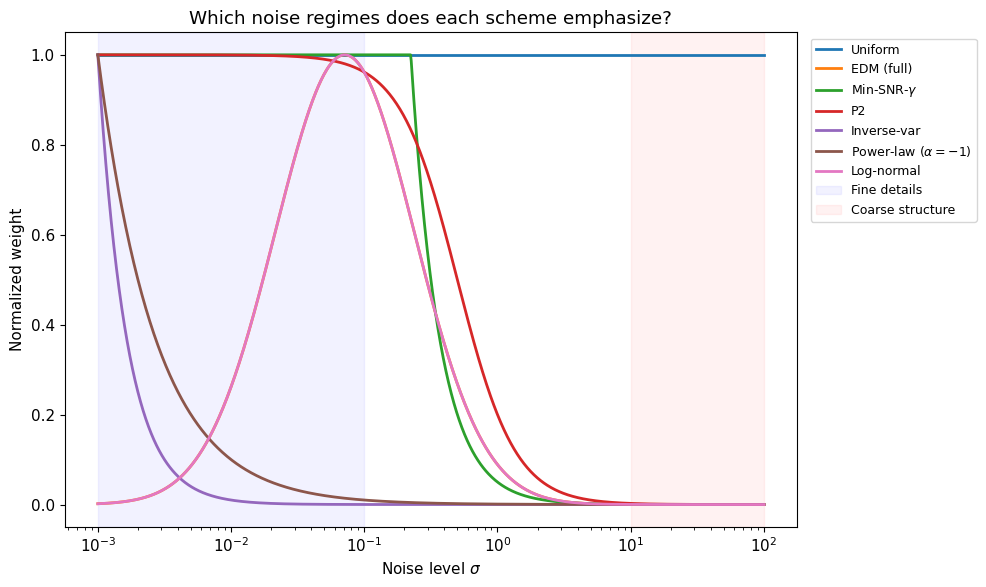

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, label in zip(scheme_names, scheme_labels):
    eta_fn, data_fn = get_weighting(name)
    w_vals = np.array([eta_fn(s) for s in sigma_range])
    w_max = np.max(w_vals[np.isfinite(w_vals)])
    if w_max > 0:
        ax.plot(sigma_range, w_vals / w_max, linewidth=2, label=label)
ax.axvspan(sigma_range[0], 0.1, alpha=0.05, color='blue', label='Fine details')
ax.axvspan(10, sigma_range[-1], alpha=0.05, color='red', label='Coarse structure')
ax.set_xscale('log')
ax.set_xlabel(r'Noise level $\sigma$'); ax.set_ylabel(r'Normalized weight')
ax.set_title('Which noise regimes does each scheme emphasize?')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

Signal fraction per mode -- shows how each eigenmode becomes invisible above its characteristic noise scale.

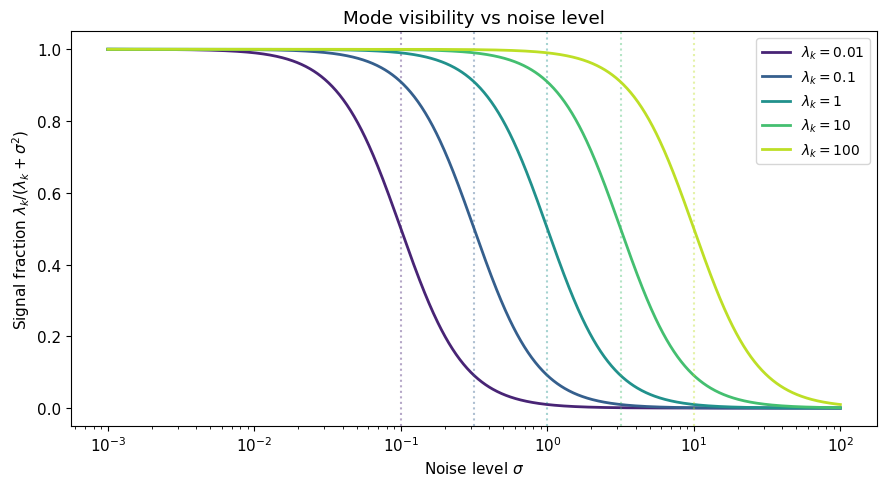

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, lambdak in enumerate(LAMBDA_K_LIST):
    signal_frac = lambdak / (lambdak + sigma_range**2)
    ax.plot(sigma_range, signal_frac, color=colors[i], linewidth=2, label=f'$\\lambda_k = {lambdak}$')
    ax.axvline(x=np.sqrt(lambdak), color=colors[i], linestyle=':', alpha=0.4)
ax.set_xscale('log')
ax.set_xlabel(r'Noise level $\sigma$'); ax.set_ylabel(r'Signal fraction $\lambda_k / (\lambda_k + \sigma^2)$')
ax.set_title(r'Mode visibility vs noise level'); ax.legend(fontsize=10); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## 3. Numerical: how weighting changes spectral learning curves
Using numerical integration to compute learning curves with arbitrary $w(\sigma)$.

In [10]:
def psi_k(sigma_, tau, lambda_k, q_k, eta, eta_scaling, data_scaling):
    term1 = lambda_k / (sigma_**2 + lambda_k)
    term2 = q_k - (lambda_k / (sigma_**2 + lambda_k))
    exponent = -2 * eta * tau * eta_scaling(sigma_) * (sigma_**2 + lambda_k) * data_scaling(sigma_)**2
    return term1 + term2 * np.exp(exponent)


def compute_Phi(sigma, tau, lambda_k, q_k, eta, eta_scaling, data_scaling, sigma_ref=1.0):
    def integrand(sigma_):
        psi = psi_k(sigma_, tau, lambda_k, q_k, eta, eta_scaling, data_scaling)
        return (psi - 1) / sigma_
    integral, _ = quad(integrand, sigma_ref, sigma, limit=10000, epsabs=1e-7, epsrel=1e-7)
    return np.exp(-integral)


def compute_learning_curves(tau_arr, lambda_k_values, sigma_T, sigma_0, q_k, eta, eta_scaling, data_scaling):
    results = {}
    for lambda_k in lambda_k_values:
        variance_arr = []
        for tau in tau_arr:
            Phi_T = compute_Phi(sigma_T, tau, lambda_k, q_k, eta, eta_scaling, data_scaling, sigma_ref=1.0)
            Phi_0 = compute_Phi(sigma_0, tau, lambda_k, q_k, eta, eta_scaling, data_scaling, sigma_ref=1.0)
            variance = sigma_T**2 * Phi_0**2 / Phi_T**2
            variance_arr.append(variance)
        results[lambda_k] = np.array(variance_arr)
    return results

Baseline: uniform weighting.

Computing uniform weighting curves...


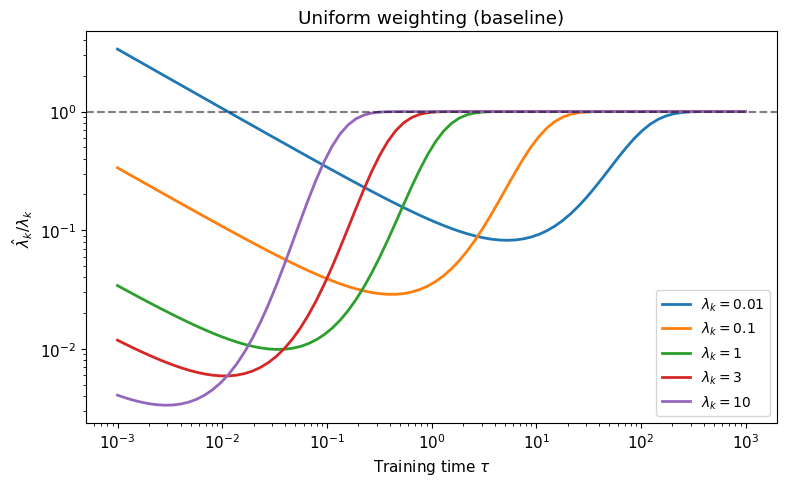

In [11]:
tau_num = np.logspace(-3, 3, 80)
lambda_k_num = [0.01, 0.1, 1, 3, 10]

eta_uniform, data_uniform = get_weighting('uniform')
print("Computing uniform weighting curves...")
results_uniform = compute_learning_curves(tau_num, lambda_k_num, SIGMA_T, SIGMA_0, Q_K, ETA, eta_uniform, data_uniform)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (lk, var_arr) in enumerate(results_uniform.items()):
    ax.plot(tau_num, var_arr / lk, linewidth=2, label=f'$\\lambda_k = {lk}$')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Training time $\tau$'); ax.set_ylabel(r'$\hat{\lambda}_k / \lambda_k$')
ax.set_title('Uniform weighting (baseline)'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

Uniform vs EDM side by side.

Computing EDM weighting curves...


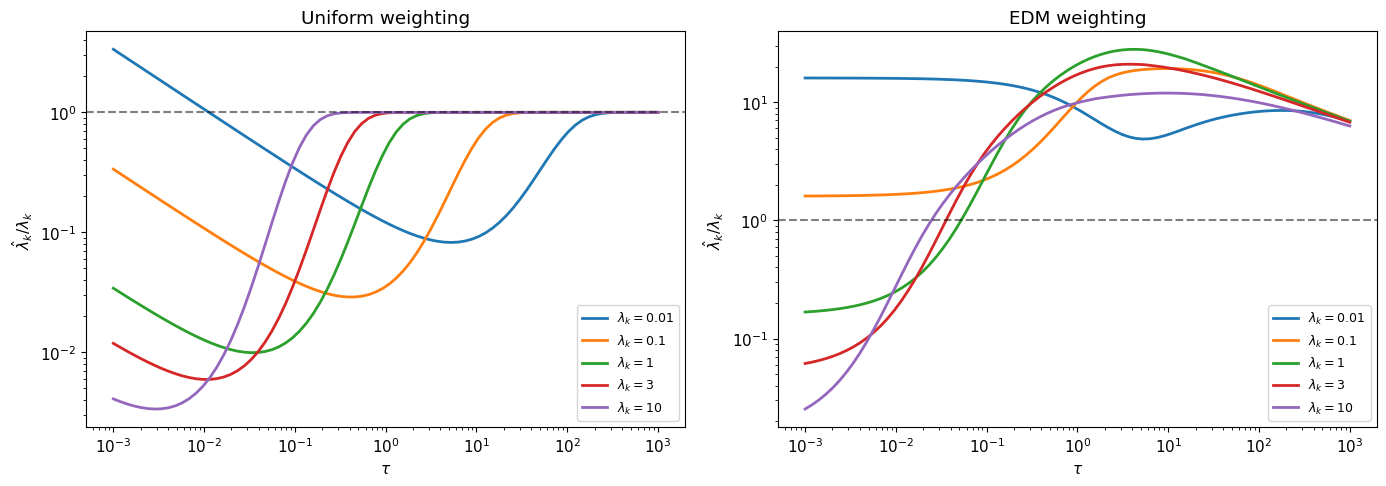

In [12]:
eta_edm, data_edm = get_weighting('edm')
print("Computing EDM weighting curves...")
results_edm = compute_learning_curves(tau_num, lambda_k_num, SIGMA_T, SIGMA_0, Q_K, ETA, eta_edm, data_edm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (results, title) in zip(axes, [(results_uniform, 'Uniform'), (results_edm, 'EDM')]):
    for i, (lk, var_arr) in enumerate(results.items()):
        ax.plot(tau_num, var_arr / lk, linewidth=2, label=f'$\\lambda_k = {lk}$')
    ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\hat{\lambda}_k / \lambda_k$')
    ax.set_title(f'{title} weighting'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Computing all 6 weighting schemes.

In [13]:
schemes = [
    ('uniform', 'Uniform', {}),
    ('edm', 'EDM', {}),
    ('min-snr-gamma', 'Min-SNR-$\\gamma$', {'gamma': 5}),
    ('p2', 'P2', {'gamma': 1}),
    ('inverse-variance', 'Inverse-var', {}),
    ('power-law', 'Power-law ($\\alpha$=-1)', {'alpha': -1}),
]

all_results = {}
for name, label, kwargs in schemes:
    print(f"Computing {label}...")
    eta_fn, data_fn = get_weighting(name, **kwargs)
    all_results[name] = compute_learning_curves(tau_num, lambda_k_num, SIGMA_T, SIGMA_0, Q_K, ETA, eta_fn, data_fn)
print("Done.")

Computing Uniform...
Computing EDM...


Computing Min-SNR-$\gamma$...


Computing P2...
Computing Inverse-var...


Computing Power-law ($\alpha$=-1)...
Done.


Learning curves for all 6 schemes.

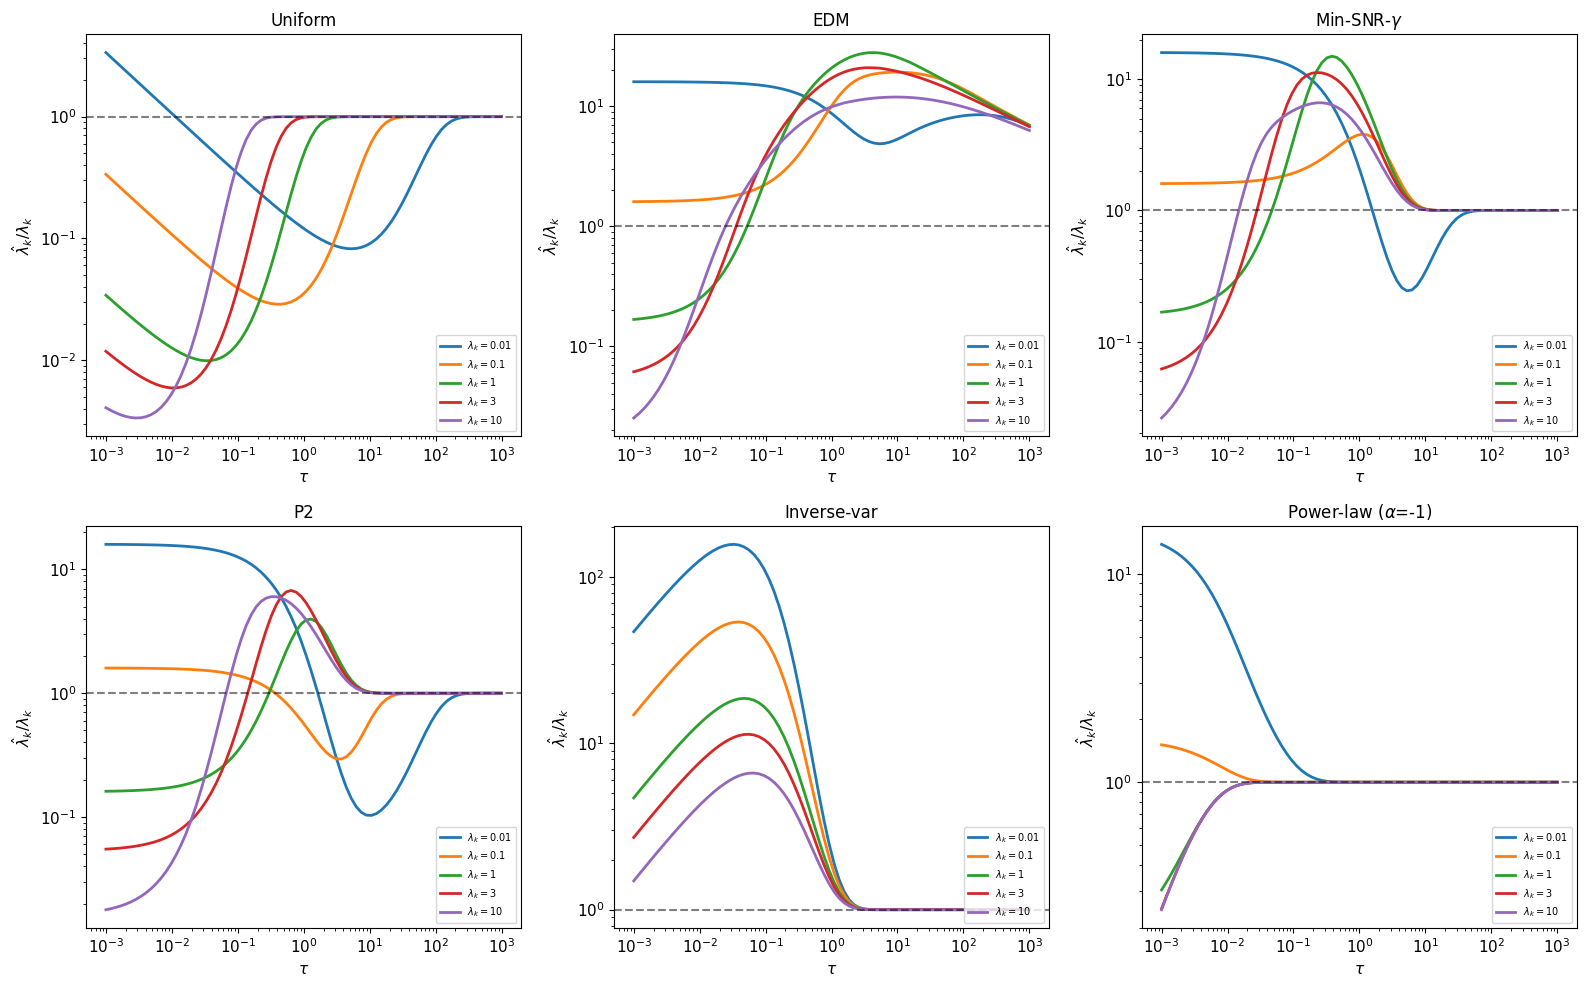

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, label, _) in enumerate(schemes):
    ax = axes[idx]
    results = all_results[name]
    for i, (lk, var_arr) in enumerate(results.items()):
        ax.plot(tau_num, var_arr / lk, linewidth=2, label=f'$\\lambda_k = {lk}$')
    ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\hat{\lambda}_k / \lambda_k$')
    ax.set_title(label, fontsize=12); ax.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()

Fitting the power-law exponent for each scheme to compare spectral bias.

In [15]:
tau_emerge = np.logspace(-4, 4, 200)
lambda_k_fit = np.logspace(-1.5, 1.5, 12)
q_k_emerge = 0.0  # zero init for clean monotonic increase

exponent_results = []

for name, label, kwargs in schemes:
    print(f"\n--- {label} ---")
    eta_fn, data_fn = get_weighting(name, **kwargs)
    results = compute_learning_curves(tau_emerge, lambda_k_fit, SIGMA_T, SIGMA_0, q_k_emerge, ETA, eta_fn, data_fn)

    emergence_data = []
    for lk in lambda_k_fit:
        var_traj = results[lk]
        initial_var = var_traj[0]
        target_var = lk
        threshold = 2 / (1 / target_var + 1 / initial_var)
        smoothed = gaussian_filter1d(var_traj, sigma=2)
        crossings = np.where(smoothed > threshold)[0]
        if len(crossings) > 0:
            emergence_data.append({'lambda_k': lk, 'tau_star': tau_emerge[crossings[0]]})

    if len(emergence_data) >= 3:
        df_em = pd.DataFrame(emergence_data)
        a, b, r2 = fit_power_law(df_em['lambda_k'].values, df_em['tau_star'].values)
        print(f"  alpha = {b:.3f}, R^2 = {r2:.4f}, n = {len(df_em)}")
        exponent_results.append({'scheme': label, 'alpha': b, 'r_squared': r2, 'a': a, 'n_points': len(df_em)})
    else:
        print(f"  Not enough crossing points ({len(emergence_data)}).")
        exponent_results.append({'scheme': label, 'alpha': np.nan, 'r_squared': np.nan, 'a': np.nan, 'n_points': len(emergence_data)})

df_exponents = pd.DataFrame(exponent_results)
print("\n" + "="*60)
print(df_exponents.to_string(index=False))


--- Uniform ---


  alpha = -1.048, R^2 = 0.9996, n = 12

--- EDM ---


  alpha = -0.960, R^2 = 0.9988, n = 12

--- Min-SNR-$\gamma$ ---


  alpha = -0.951, R^2 = 0.9988, n = 12

--- P2 ---


  alpha = -0.990, R^2 = 0.9999, n = 12

--- Inverse-var ---


  alpha = -0.006, R^2 = 0.2308, n = 12

--- Power-law ($\alpha$=-1) ---


  alpha = -0.669, R^2 = 0.9478, n = 12

                 scheme     alpha  r_squared        a  n_points
                Uniform -1.048319   0.999556 0.023543        12
                    EDM -0.959670   0.998780 0.007996        12
       Min-SNR-$\gamma$ -0.950908   0.998799 0.007575        12
                     P2 -0.989563   0.999859 0.033571        12
            Inverse-var -0.005669   0.230769 0.000211        12
Power-law ($\alpha$=-1) -0.668986   0.947805 0.000755        12


Bar chart comparing the spectral bias exponent across schemes.

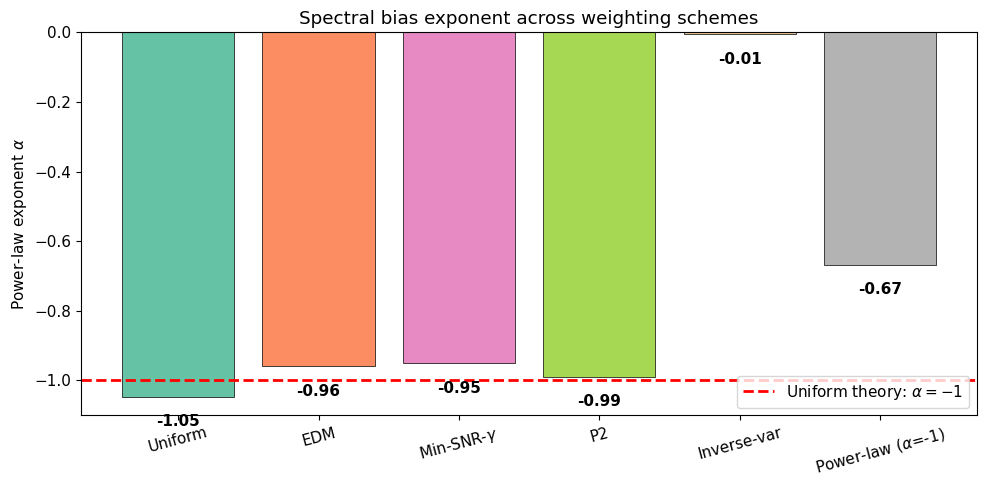

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
valid_df = df_exponents.dropna(subset=['alpha'])
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(valid_df)))
bars = ax.bar(valid_df['scheme'], valid_df['alpha'], color=bar_colors, edgecolor='k', linewidth=0.5)
for bar, alpha_val in zip(bars, valid_df['alpha']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05,
            f'{alpha_val:.2f}', ha='center', va='top', fontsize=11, fontweight='bold')
ax.axhline(y=-1, color='r', linestyle='--', linewidth=2, label=r'Uniform theory: $\alpha = -1$')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_ylabel(r'Power-law exponent $\alpha$')
ax.set_title(r'Spectral bias exponent across weighting schemes')
ax.legend(fontsize=11); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

## References
- Wang et al., arXiv:2503.03206
- Karras et al., NeurIPS 2022 (EDM)
- Hang et al., CVPR 2023 (Min-SNR)
- Choi et al., CVPR 2022 (P2)